In [ ]:
from pandas import read_csv
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

In [ ]:
def get_train_test(url, split_percent=0.8):
    df = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    # Point for splitting data into train and test
    split = int(n*split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = '/content/tesla_stock_2015_2022 (1).csv'
train_data, test_data, data = get_train_test(sunspots_url)

In [ ]:
# Prepare the input X and target Y
def get_XY(dat, time_steps):
    # Indices of target array
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]
    # Prepare X
    rows_x = len(Y)
    X = dat[range(time_steps*rows_x)]
    X = np.reshape(X, (rows_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [ ]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()

    model.add(LSTM(hidden_units, input_shape=input_shape, return_sequences=True,
                   activation=activation[0]))

    model.add(LSTM(hidden_units, input_shape=input_shape, return_sequences=True,
                   activation=activation[0]))

    model.add(LSTM(hidden_units, input_shape=input_shape, return_sequences=True,
                   activation=activation[0]))

    model.add(LSTM(hidden_units, input_shape=input_shape,
                   activation=activation[0]))

    model.add(Dropout(0.2))

    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

model = create_RNN(hidden_units=50, dense_units=1, input_shape=(time_steps,1),
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, validation_data=(testX, testY), epochs=20, batch_size=1, verbose=2)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


109/109 - 7s - 63ms/step - loss: 0.0027 - val_loss: 0.0058
Epoch 2/20
109/109 - 1s - 13ms/step - loss: 6.2274e-04 - val_loss: 0.1149
Epoch 3/20
109/109 - 1s - 13ms/step - loss: 0.0020 - val_loss: 0.0092
Epoch 4/20
109/109 - 2s - 14ms/step - loss: 9.7719e-04 - val_loss: 0.0047
Epoch 5/20
109/109 - 3s - 24ms/step - loss: 5.5690e-04 - val_loss: 0.0937
Epoch 6/20
109/109 - 2s - 14ms/step - loss: 7.4249e-04 - val_loss: 0.0135
Epoch 7/20
109/109 - 1s - 13ms/step - loss: 7.4847e-04 - val_loss: 0.0638
Epoch 8/20
109/109 - 1s - 13ms/step - loss: 2.6143e-04 - val_loss: 0.0328
Epoch 9/20
109/109 - 1s - 13ms/step - loss: 3.4678e-04 - val_loss: 0.0295
Epoch 10/20
109/109 - 1s - 13ms/step - loss: 4.3508e-04 - val_loss: 0.0134
Epoch 11/20
109/109 - 1s - 13ms/step - loss: 2.9612e-04 - val_loss: 0.0167
Epoch 12/20
109/109 - 1s - 13ms/step - loss: 2.5685e-04 - val_loss: 0.0113
Epoch 13/20
109/109 - 2s - 23ms/step - loss: 1.2288e-04 - val_loss: 0.0090
Epoch 14/20
109/109 - 2s - 15ms/step - loss: 0.0014 -

In [ ]:
def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Raíz do Erro Médio Quadrático para Treino: %.3f' % (train_rmse))
    print('Raíz do Erro Médio Quadrático para Teste: %.3f' % (test_rmse))

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raíz do Erro Médio Quadrático para Treino: 0.024
Raíz do Erro Médio Quadrático para Teste: 0.084


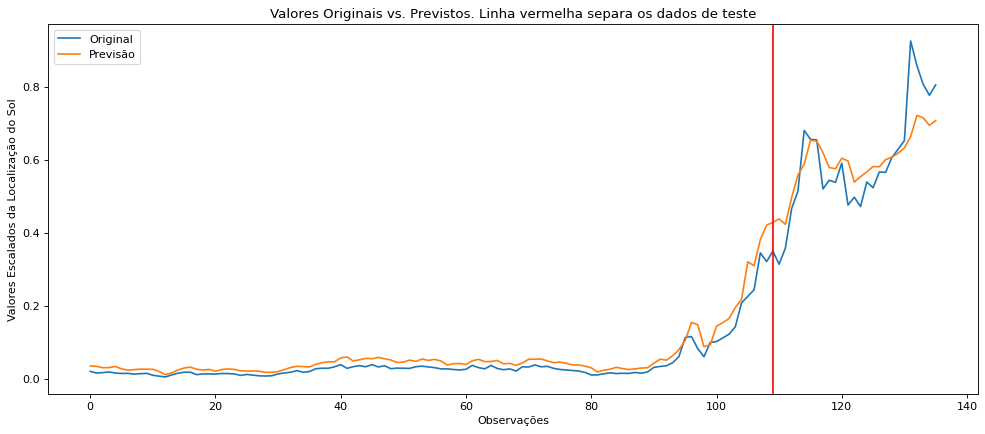

In [ ]:
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Original', 'Previsão'])
    plt.xlabel('Observações')
    plt.ylabel('Valores Escalados da Localização do Sol')
    plt.title('Valores Originais vs. Previstos. Linha vermelha separa os dados de teste')
plot_result(trainY, testY, train_predict, test_predict)